In [36]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict
import json
from matplotlib.ticker import MaxNLocator


In [19]:
reactive_result_file = 'motivational_results/infra-1/results-reactive/20250227-122803-451194/0/peak-config.json'
with open(reactive_result_file, 'r')  as fd:
    reactive_obj = json.load(fd)
    list1, list2 = zip(*reactive_obj['penaltyDistributionOverTime'])
    reactive_penalty_over_time = pd.DataFrame({'time': list1, 'penalty': list2})
    reactive_system_events_df = pd.DataFrame(reactive_obj['systemEvents'])

In [4]:
reactive_obj.keys()

dict_keys(['policy', 'endTime', 'traceFile', 'unusedPlatforms', 'unusedNodes', 'averageOccupation', 'averageElapsedTime', 'averagePullTime', 'averageColdStartTime', 'averageExecutionTime', 'averageWaitTime', 'averageQueueTime', 'averageInitializationTime', 'averageComputeTime', 'averageCommunicationsTime', 'penaltyProportion', 'localDependenciesProportion', 'localCommunicationsProportion', 'nodeCacheHitsProportion', 'taskCacheHitsProportion', 'coldStartProportion', 'taskResponseTimeDistribution', 'applicationResponseTimeDistribution', 'penaltyDistributionOverTime', 'energy', 'reclaimableEnergy', 'applicationResults', 'nodeResults', 'taskResults', 'scaleEvents', 'systemEvents'])

<Axes: xlabel='time', ylabel='penalty'>

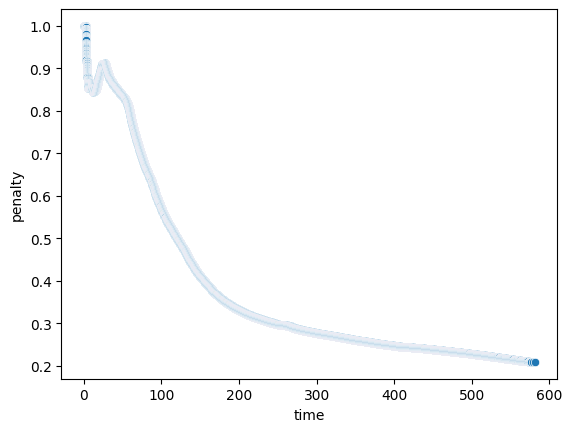

In [14]:
sns.scatterplot(x='time', y='penalty', data=reactive_penalty_over_time)

<Axes: xlabel='timestamp', ylabel='count'>

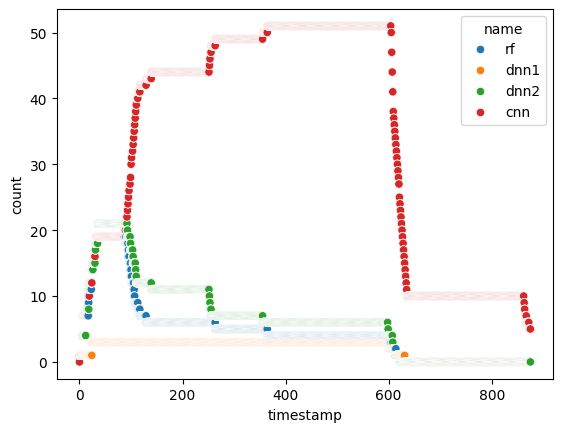

In [22]:
sns.scatterplot(x='timestamp', y='count', hue='name', data=reactive_system_events_df)

In [18]:
proactive_result_file = 'motivational_results/infra-1/results-proactive/origin-1-target-1-model-60-90-120-150-180-210-240-270/20250227-123909-937414/0/peak-config.json'
with open(proactive_result_file, 'r')  as fd:
    proactive_obj = json.load(fd)
    list1, list2 = zip(*proactive_obj['penaltyDistributionOverTime'])
    proactive_penalty_over_time = pd.DataFrame({'time': list1, 'penalty': list2})
    proactive_system_events_df = pd.DataFrame(proactive_obj['systemEvents'])

<Axes: xlabel='time', ylabel='penalty'>

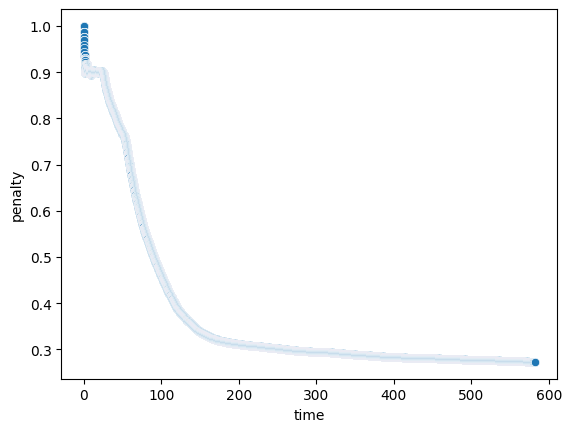

In [25]:
sns.scatterplot(x='time', y='penalty', data=proactive_penalty_over_time)

<Axes: xlabel='timestamp', ylabel='count'>

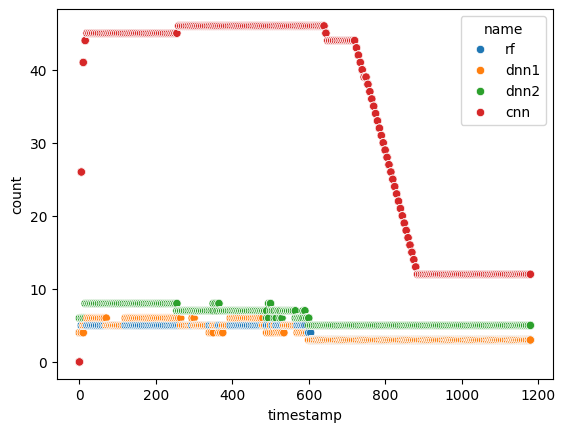

In [24]:
sns.scatterplot(x='timestamp', y='count', hue='name', data=proactive_system_events_df)

In [29]:
proactive_origin_0_target_1  = 'motivational_results/infra-1/results-proactive/origin-0-target-1-model-60-90-120-150-180-210-240-270/20250227-130521-807075/0/peak-config.json'
with open(proactive_origin_0_target_1, 'r')  as fd:
    proactive_origin_0_target_1_obj = json.load(fd)
    list1, list2 = zip(*proactive_origin_0_target_1_obj['penaltyDistributionOverTime'])
    proactive_origin_0_target_1_proactive_penalty_over_time = pd.DataFrame({'time': list1, 'penalty': list2})
    proactive_origin_0_target_1_system_events_df = pd.DataFrame(proactive_origin_0_target_1_obj['systemEvents'])
    

<Axes: xlabel='time', ylabel='penalty'>

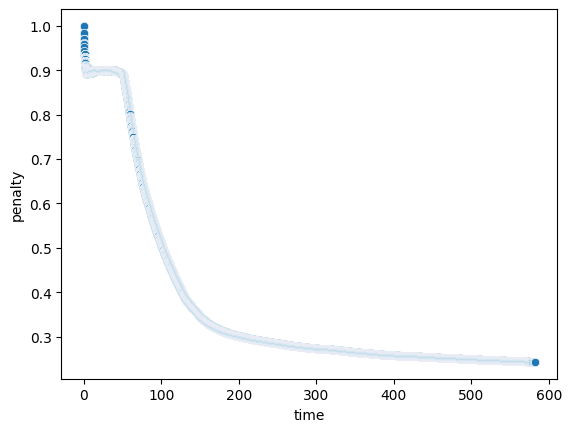

In [30]:
sns.scatterplot(x='time', y='penalty', data=proactive_origin_0_target_1_proactive_penalty_over_time)

<Axes: xlabel='timestamp', ylabel='count'>

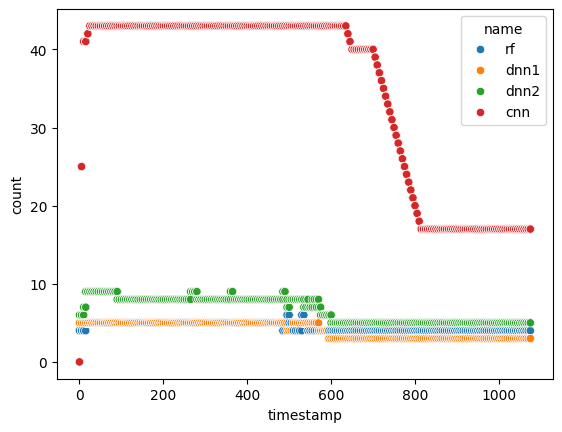

In [31]:
sns.scatterplot(x='timestamp', y='count', hue='name', data=proactive_origin_0_target_1_system_events_df)

In [41]:
def plot_comparison(original_data):
    # Create dictionaries to store counts per timestamp
    original_counts = defaultdict(lambda: defaultdict(int))

    # Count events per timestamp for both datasets
    for event in original_data:
        timestamp = int(event['timestamp'])
        app_name = event['application']['name']
        original_counts[app_name][timestamp] += 1

    # Get unique applications
    apps = set(original_counts.keys())

    # Calculate number of subplots needed
    n_apps = len(apps)
    n_cols = min(2, n_apps)
    n_rows = (n_apps + n_cols - 1) // n_cols

    # Create figure
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
    if n_apps == 1:
        axes = np.array([axes])
    axes = axes.flatten()

    # Plot each application
    for idx, app_name in enumerate(sorted(apps)):
        ax = axes[idx]

        # Get time range for this application
        timestamps_orig = sorted(original_counts[app_name].keys())
        min_time = int(min(timestamps_orig))
        max_time = int(max(timestamps_orig))

        # Create continuous time series
        time_range = range(min_time, max_time + 1)
        orig_values = [original_counts[app_name][t] for t in time_range]

        # Normalize timestamps for better readability
        time_range_norm = [t - min_time for t in time_range]

        # Plot
        ax.plot(time_range_norm, orig_values, label='Original', color='blue', alpha=0.6)

        ax.set_title(f'Application: {app_name}')
        ax.set_xlabel('Seconds from start')
        ax.set_ylabel('Events per second')
        ax.legend()
        ax.grid(True, alpha=0.3)

        # Force y-axis to use integers
        ax.yaxis.set_major_locator(MaxNLocator(integer=True))

    # Remove any unused subplots
    for idx in range(n_apps, len(axes)):
        fig.delaxes(axes[idx])

    plt.tight_layout()
    return fig

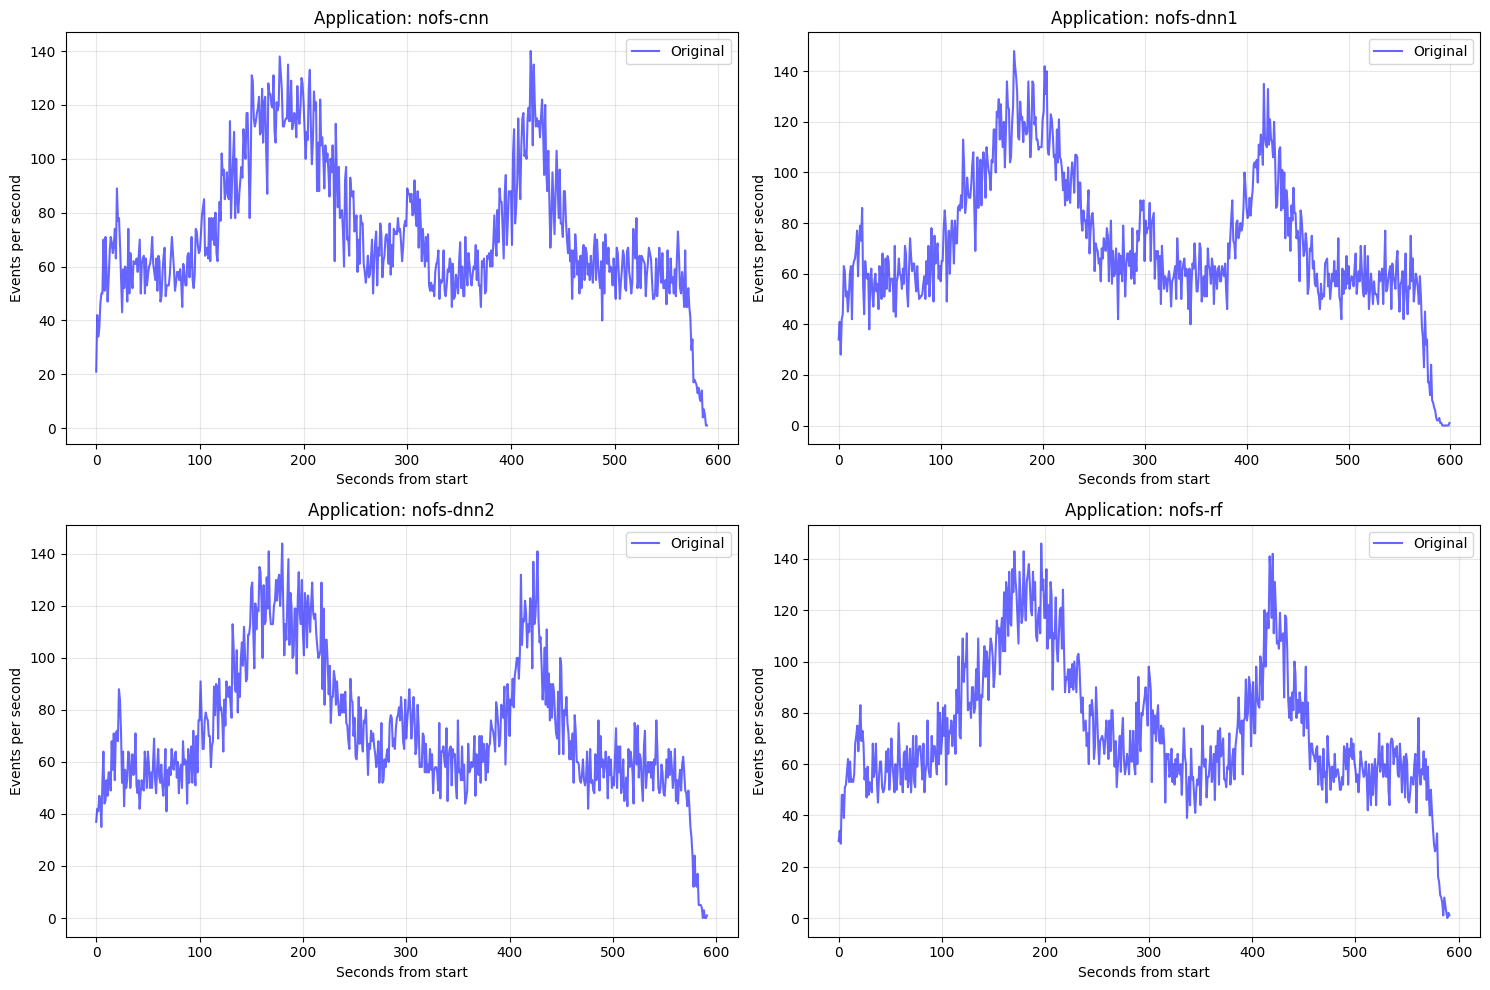

In [42]:
with open('data/nofs-ids/traces/workload-flatten-peak_configs-0.json') as fd:
    workload = json.load(fd)
    plot_comparison(workload['events'])

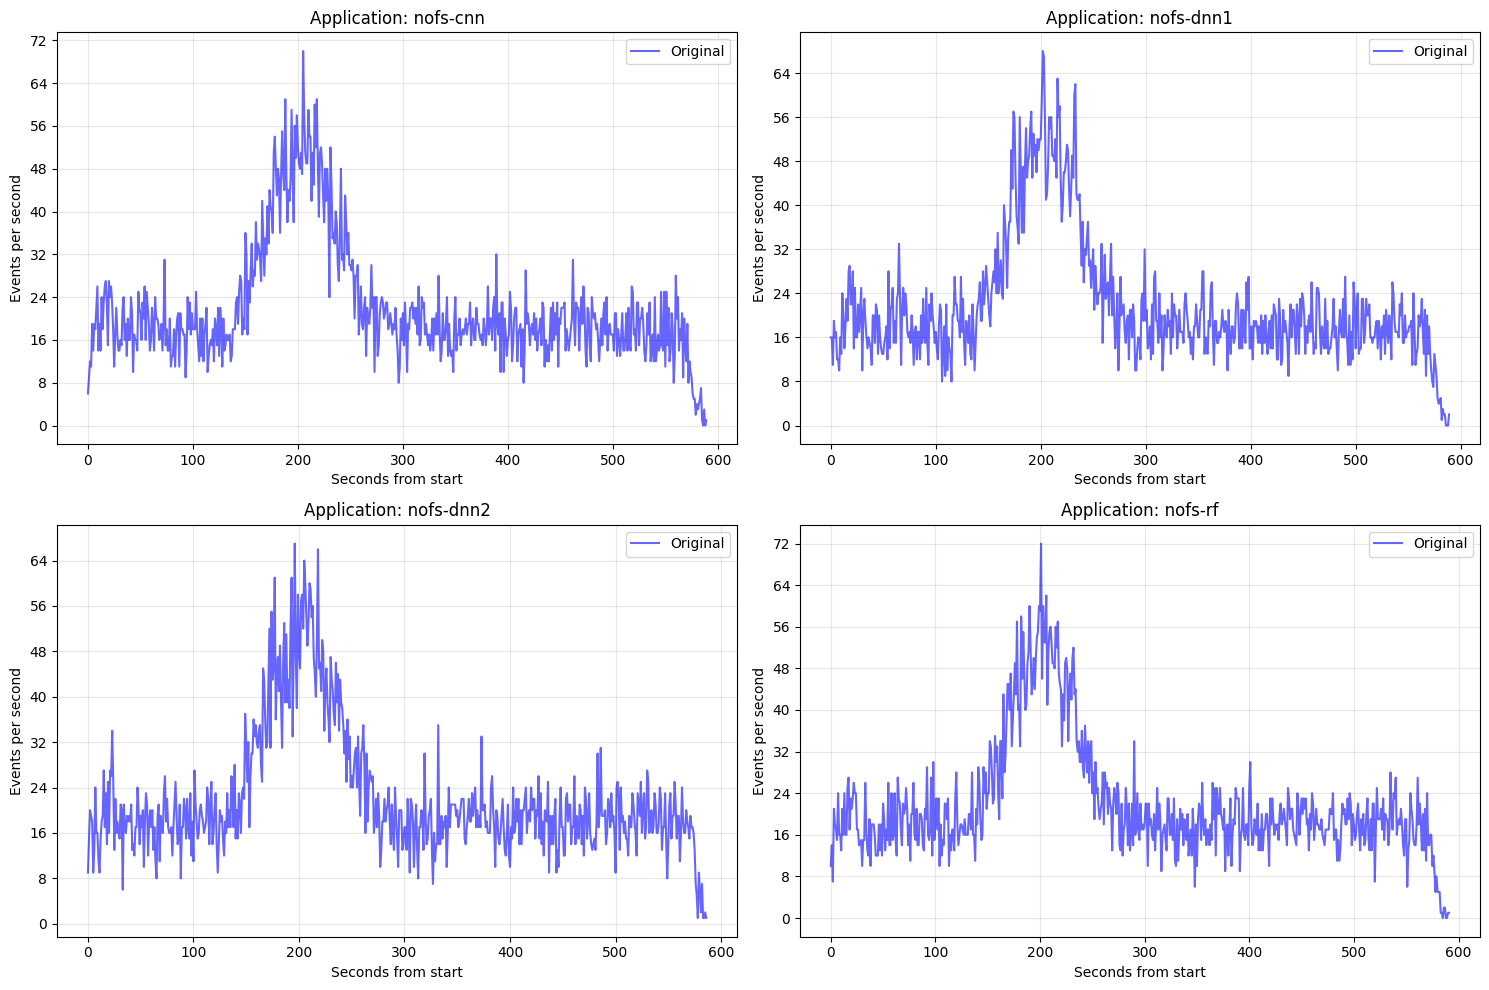

In [43]:
with open('data/nofs-ids/traces/workload-90-600-nofs-cnn-peak_pattern.json') as fd:
    workload = json.load(fd)
    plot_comparison(workload['events'])